<a href="https://colab.research.google.com/github/mbenedicto99/Astro_TarantulaNebula/blob/main/simulacao_propulsao_ml_multiplanetario.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulação Didática de Propulsão e Ascensão de um Foguete de 1 tonelada

Este notebook apresenta uma sequência didática para estudar, de forma simplificada, o problema de lançar um veículo com massa definida por `VEHICLE_MASS`.

A ideia não é reproduzir um software de engenharia aeroespacial de alta fidelidade. O objetivo é entender como se relacionam massa inicial, massa de propelente, impulso específico (`Isp`), empuxo, aceleração, gravidade, arrasto, altitude, velocidade, `delta-v`, Machine Learning como *surrogate model* e otimização bayesiana.

## Hipóteses

A simulação dinâmica é **unidimensional e vertical**. Ela não modela órbita, rotação da Terra, trajetória inclinada, controle de atitude, múltiplos estágios, dinâmica 6-DOF, atmosfera completa ou motores específicos. Os resultados são educacionais, não um projeto real de veículo lançador.

NASA-CEA: https://software.nasa.gov/software/LEW-17687-1


In [ ]:
# Bibliotecas e parâmetros globais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import norm

np.random.seed(42)

# ============================================================
# CONFIGURAÇÃO GLOBAL DO CENÁRIO
# Altere SOMENTE esta célula para simular outro corpo celeste
# e/ou outra massa inicial do veículo.
# ============================================================

BODY_NAME = "Terra"

# Corpo celeste
SURFACE_GRAVITY = 9.80665       # m/s²
BODY_RADIUS = 6_371_000         # m

# Atmosfera simplificada
SURFACE_DENSITY = 1.225         # kg/m³
ATMOSPHERE_SCALE_HEIGHT = 8500  # m

# Veículo e referência
VEHICLE_MASS = 1000             # kg
REFERENCE_ALTITUDE = 100_000    # m

print(f"Corpo celeste: {BODY_NAME}")
print(f"Gravidade superficial: {SURFACE_GRAVITY:.4f} m/s²")
print(f"Raio: {BODY_RADIUS/1000:,.1f} km")
print(f"Massa inicial do veículo: {VEHICLE_MASS:,.0f} kg")
print(f"Altitude de referência: {REFERENCE_ALTITUDE/1000:.0f} km")


Corpo celeste: Terra
Gravidade superficial: 9.8066 m/s²
Raio: 6,371.0 km
Massa inicial do veículo: 1,000 kg
Altitude de referência: 100 km



## Parâmetros globais

Todo o notebook usa as variáveis definidas na célula anterior.

`VEHICLE_MASS` controla a massa inicial total do veículo. `SURFACE_GRAVITY`, `BODY_RADIUS`, `SURFACE_DENSITY` e `ATMOSPHERE_SCALE_HEIGHT` descrevem o corpo celeste. `REFERENCE_ALTITUDE` define a altitude usada nos exemplos de energia.

Para testar outro planeta ou outra massa, altere apenas esses valores e execute novamente o notebook do início ao fim.

Para um corpo sem atmosfera, uma aproximação simples é usar `SURFACE_DENSITY = 0`.


In [ ]:
# Exemplos de parâmetros para outros corpos celestes
# Use estes valores como referência e copie os desejados para a célula global.

planet_examples = pd.DataFrame([
    ["Terra", 9.80665, 6371.0, 1.225, 8500],
    ["Marte", 3.72076, 3389.5, 0.020, 11100],
    ["Lua", 1.62, 1737.4, 0.0, 1.0],
], columns=[
    "body",
    "gravity_m_s2",
    "radius_km",
    "surface_density_kg_m3",
    "scale_height_m",
])

planet_examples


,body,gravity_m_s2,radius_km,surface_density_kg_m3,scale_height_m
0,Terra,9.80665,6371.0,1.225,8500.0
1,Marte,3.72076,3389.5,0.020,11100.0
2,Lua,1.62000,1737.4,0.000,1.0


## 1. Energia mínima para ganhar altitude no corpo celeste escolhido

Perto da superfície terrestre:

\[
E_p \approx mgh
\]

Para a massa definida em `VEHICLE_MASS` chegando à altitude definida em `REFERENCE_ALTITUDE`, essa conta representa apenas a energia potencial gravitacional ideal. Ela não inclui arrasto, perdas gravitacionais, aceleração do propelente ou ineficiências.


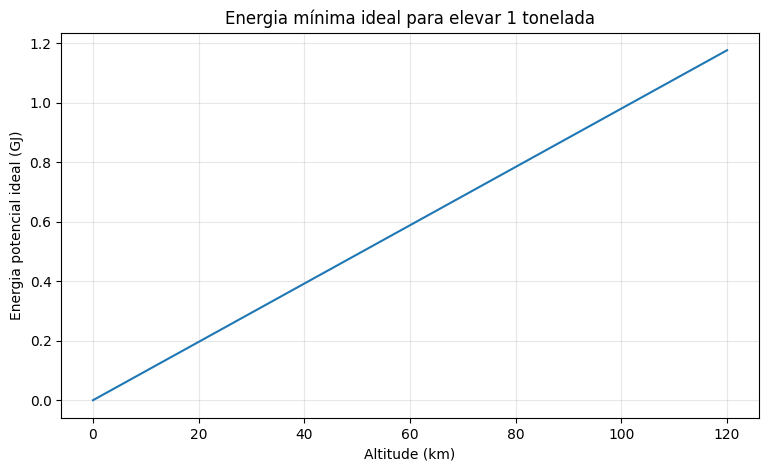

Energia ideal para 100 km: 0.981 GJ
Equivalente: 272.4 kWh


In [ ]:
massa = 1000
altitudes_km = np.linspace(0, 120, 121)
energia_GJ = massa * SURFACE_GRAVITY * (altitudes_km * 1000) / 1e9

plt.figure(figsize=(9, 5))
plt.plot(altitudes_km, energia_GJ)
plt.xlabel("Altitude (km)")
plt.ylabel("Energia potencial ideal (GJ)")
plt.title("Energia mínima ideal para elevar 1 tonelada")
plt.grid(alpha=0.3)
plt.show()

E_ref = massa * SURFACE_GRAVITY * REFERENCE_ALTITUDE
print(f"Energia ideal para {REFERENCE_ALTITUDE/1000:.0f} km: {E_ref/1e9:.3f} GJ")
print(f"Equivalente: {E_ref/3.6e6:.1f} kWh")


## 2. Equação de Tsiolkovsky

\[
\Delta v = v_e \ln\left(\frac{m_0}{m_f}\right)
\]

com

\[
v_e = I_{sp}g_0
\]

Aqui usamos valores genéricos de `Isp` apenas para visualizar a relação matemática.


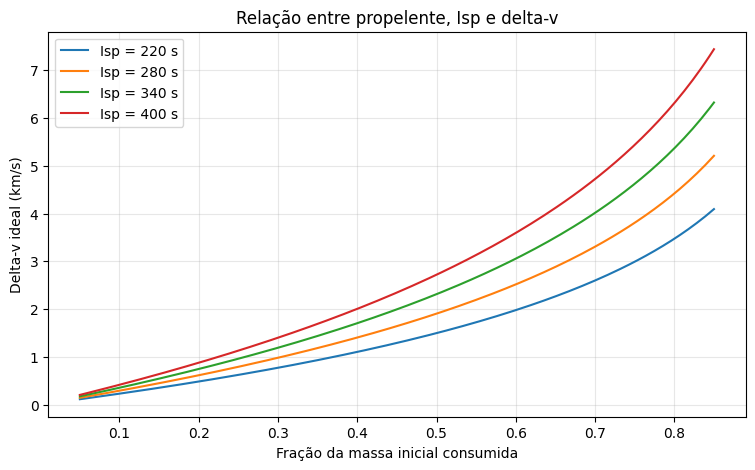

In [ ]:
def tsiolkovsky_delta_v(m0, mf, isp):
    ve = isp * SURFACE_GRAVITY
    return ve * np.log(m0 / mf)

m0 = VEHICLE_MASS
mass_fraction = np.linspace(0.15, 0.95, 150)

plt.figure(figsize=(9, 5))
for isp in [220, 280, 340, 400]:
    mf = m0 * mass_fraction
    dv = tsiolkovsky_delta_v(m0, mf, isp) / 1000
    plt.plot(1 - mass_fraction, dv, label=f"Isp = {isp} s")

plt.xlabel("Fração da massa inicial consumida")
plt.ylabel("Delta-v ideal (km/s)")
plt.title("Relação entre propelente, Isp e delta-v")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 3. Modelo dinâmico vertical simplificado

O modelo acompanha altitude, velocidade e massa. As forças consideradas são empuxo, peso e arrasto.

\[
F = T - mg - D
\]

com

\[
D = \frac{1}{2}\rho v^2 C_d A
\]

A densidade atmosférica é aproximada por uma exponencial.


In [ ]:
def atmosphere_density(h):
    h = max(h, 0)
    return SURFACE_DENSITY * np.exp(-h / ATMOSPHERE_SCALE_HEIGHT)

def gravity(h):
    return SURFACE_GRAVITY * (BODY_RADIUS / (BODY_RADIUS + max(h, 0)))**2

def simulate_vertical_ascent(total_mass=VEHICLE_MASS, propellant_mass=0.65 * VEHICLE_MASS, dry_mass=0.35 * VEHICLE_MASS,
                             thrust=22_000, isp=300, cd=0.45, area=0.8,
                             max_time=180, dt=0.1):
    assert abs(propellant_mass + dry_mass - total_mass) < 1e-6
    mdot = thrust / (isp * SURFACE_GRAVITY)
    burn_time = propellant_mass / mdot

    def dynamics(t, y):
        h, v, m = y
        burning = (t <= burn_time) and (m > dry_mass)
        T = thrust if burning else 0.0
        dm = -mdot if burning else 0.0
        rho = atmosphere_density(h)
        g = gravity(h)
        drag = 0.5 * rho * v * abs(v) * cd * area
        dv = (T - m * g - drag) / m
        return [v, dv, dm]

    t_eval = np.arange(0, max_time + dt, dt)
    sol = solve_ivp(dynamics, [0, max_time], [0, 0, total_mass],
                    t_eval=t_eval, rtol=1e-7, atol=1e-9)

    df = pd.DataFrame({
        "time_s": sol.t,
        "altitude_m": sol.y[0],
        "velocity_m_s": sol.y[1],
        "mass_kg": sol.y[2],
    })
    df["altitude_km"] = df["altitude_m"] / 1000
    df["density_kg_m3"] = [atmosphere_density(h) for h in df["altitude_m"]]
    return df, burn_time


In [ ]:
params = dict(total_mass=VEHICLE_MASS, propellant_mass=0.65 * VEHICLE_MASS, dry_mass=0.35 * VEHICLE_MASS,
              thrust=22_000, isp=300, cd=0.45, area=0.8, max_time=180)

df, burn_time = simulate_vertical_ascent(**params)
print(f"Tempo de queima aproximado: {burn_time:.1f} s")
print(f"Altitude máxima: {df['altitude_km'].max():.2f} km")
print(f"Velocidade máxima: {df['velocity_m_s'].max():.1f} m/s")


Tempo de queima aproximado: 86.9 s
Altitude máxima: 103.02 km
Velocidade máxima: 1206.4 m/s


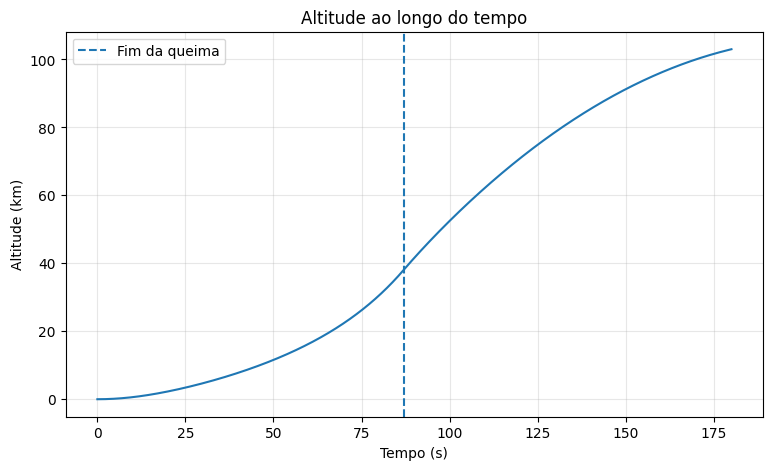

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(df["time_s"], df["altitude_km"])
plt.axvline(burn_time, linestyle="--", label="Fim da queima")
plt.xlabel("Tempo (s)")
plt.ylabel("Altitude (km)")
plt.title("Altitude ao longo do tempo")
plt.legend(); plt.grid(alpha=0.3); plt.show()


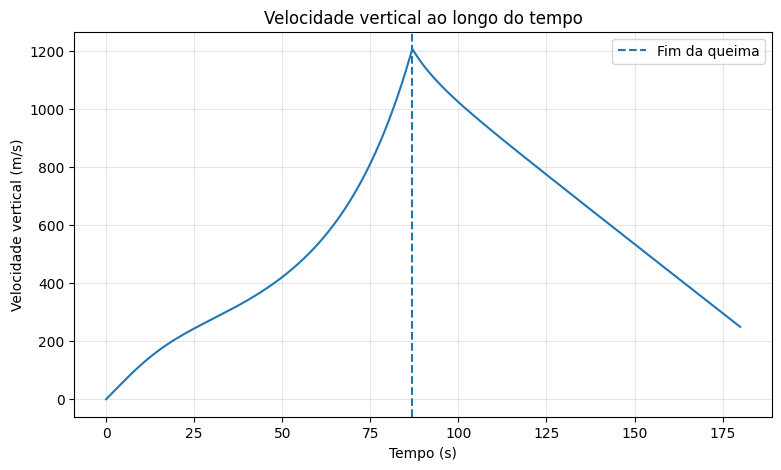

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(df["time_s"], df["velocity_m_s"])
plt.axvline(burn_time, linestyle="--", label="Fim da queima")
plt.xlabel("Tempo (s)")
plt.ylabel("Velocidade vertical (m/s)")
plt.title("Velocidade vertical ao longo do tempo")
plt.legend(); plt.grid(alpha=0.3); plt.show()


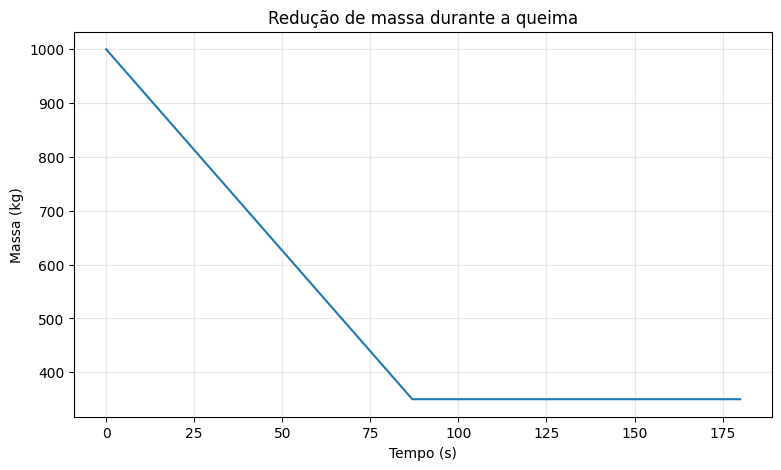

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(df["time_s"], df["mass_kg"])
plt.xlabel("Tempo (s)")
plt.ylabel("Massa (kg)")
plt.title("Redução de massa durante a queima")
plt.grid(alpha=0.3); plt.show()


## 4. Comparando cenários

Variamos apenas o `Isp`, mantendo os demais parâmetros iguais. O objetivo é observar tendências, não representar motores reais específicos.

In [ ]:
resultados = []
for isp in [220, 260, 300, 340, 380]:
    p = params.copy(); p["isp"] = isp
    sim, bt = simulate_vertical_ascent(**p)
    resultados.append({
        "Isp_s": isp,
        "burn_time_s": bt,
        "max_altitude_km": sim["altitude_km"].max(),
        "max_velocity_m_s": sim["velocity_m_s"].max(),
    })
comparison = pd.DataFrame(resultados)
comparison


,Isp_s,burn_time_s,max_altitude_km,max_velocity_m_s
0,220,63.743225,34.602448,698.976917
1,260,75.332902,60.117291,918.010140
2,300,86.922580,103.018759,1206.390815
3,340,98.512257,143.830266,1546.455557
4,380,110.101934,176.661308,1904.663597


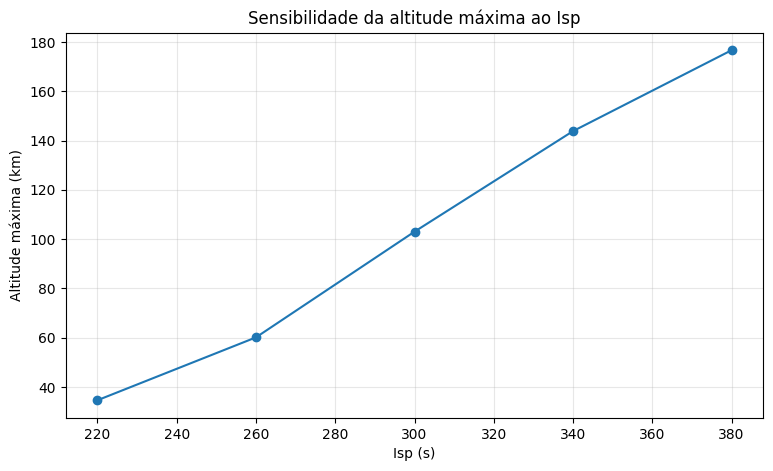

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(comparison["Isp_s"], comparison["max_altitude_km"], marker="o")
plt.xlabel("Isp (s)")
plt.ylabel("Altitude máxima (km)")
plt.title("Sensibilidade da altitude máxima ao Isp")
plt.grid(alpha=0.3); plt.show()


## 5. Gerando um conjunto de simulações

Vamos criar experimentos virtuais variando `Isp`, empuxo, massa de propelente, coeficiente de arrasto e área frontal. A saída será a altitude máxima.

In [ ]:
def generate_dataset(n=300):
    rows = []
    for _ in range(n):
        isp = np.random.uniform(220, 380)
        thrust = np.random.uniform(14_000, 30_000)
        propellant_mass = np.random.uniform(0.45 * VEHICLE_MASS, 0.75 * VEHICLE_MASS)
        dry_mass = VEHICLE_MASS - propellant_mass
        cd = np.random.uniform(0.25, 0.8)
        area = np.random.uniform(0.4, 1.2)
        sim, _ = simulate_vertical_ascent(
            total_mass=VEHICLE_MASS, propellant_mass=propellant_mass,
            dry_mass=dry_mass, thrust=thrust, isp=isp,
            cd=cd, area=area, max_time=150, dt=0.25)
        rows.append({
            "isp": isp, "thrust_N": thrust,
            "propellant_mass_kg": propellant_mass,
            "cd": cd, "area_m2": area,
            "max_altitude_km": max(0, sim["altitude_km"].max()),
            "max_velocity_m_s": max(0, sim["velocity_m_s"].max()),
        })
    return pd.DataFrame(rows)

dataset = generate_dataset(300)
dataset.head()


,isp,thrust_N,propellant_mass_kg,cd,area_m2,max_altitude_km,max_velocity_m_s
0,279.926419,29211.428903,669.598183,0.579262,0.524815,96.985854,1284.568225
1,244.959123,14929.337795,709.852844,0.580613,0.966458,41.620033,677.716087
2,223.293519,29518.557635,699.732792,0.366787,0.545460,86.937398,1242.331587
3,249.344722,18867.875887,607.426929,0.487570,0.632983,47.735142,763.620334
4,317.896463,16231.901770,537.643395,0.451499,0.764856,51.217564,730.840284


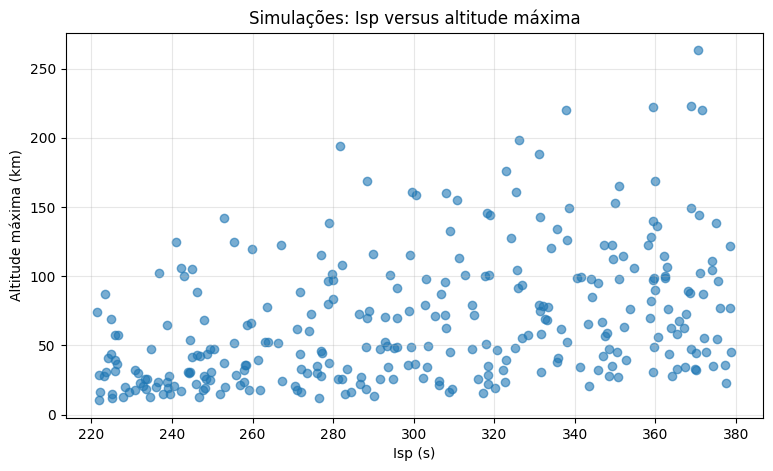

In [ ]:
plt.figure(figsize=(9, 5))
plt.scatter(dataset["isp"], dataset["max_altitude_km"], alpha=0.6)
plt.xlabel("Isp (s)")
plt.ylabel("Altitude máxima (km)")
plt.title("Simulações: Isp versus altitude máxima")
plt.grid(alpha=0.3); plt.show()


## 6. Gaussian Process como surrogate model

O modelo aprende a aproximar a saída da simulação física e também estima a incerteza da previsão.

In [ ]:
features = ["isp", "thrust_N", "propellant_mass_kg", "cd", "area_m2"]
X = dataset[features]
y = dataset["max_altitude_km"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

kernel = ConstantKernel(1.0, (1e-2, 1e3)) * RBF(length_scale=np.ones(len(features)), length_scale_bounds=(1e-2, 1e3)) + WhiteKernel(noise_level=1e-3)

gp = make_pipeline(StandardScaler(), GaussianProcessRegressor(
    kernel=kernel, normalize_y=True, n_restarts_optimizer=1, random_state=42))

gp.fit(X_train, y_train)
pred = gp.predict(X_test)
print(f"MAE: {mean_absolute_error(y_test, pred):.3f} km")
print(f"R²:  {r2_score(y_test, pred):.3f}")


MAE: 1.511 km
R²:  0.997


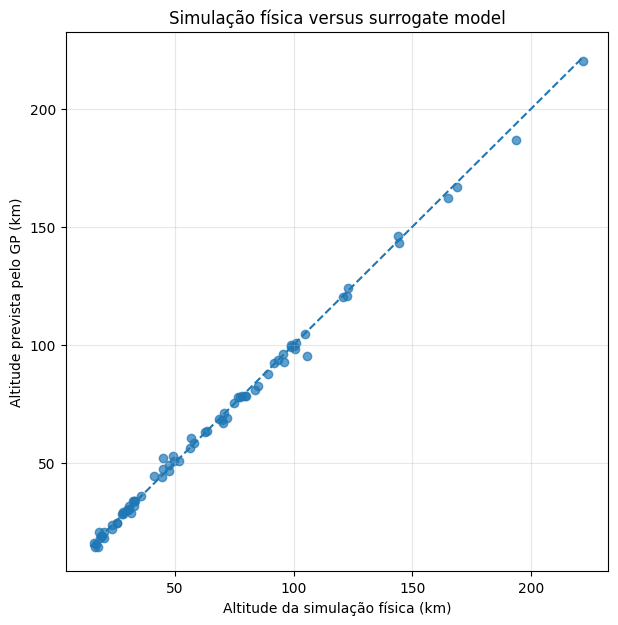

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred, alpha=0.7)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Altitude da simulação física (km)")
plt.ylabel("Altitude prevista pelo GP (km)")
plt.title("Simulação física versus surrogate model")
plt.grid(alpha=0.3); plt.show()


## 7. Incerteza do Gaussian Process

Fixamos quase todos os parâmetros e variamos apenas o `Isp`.

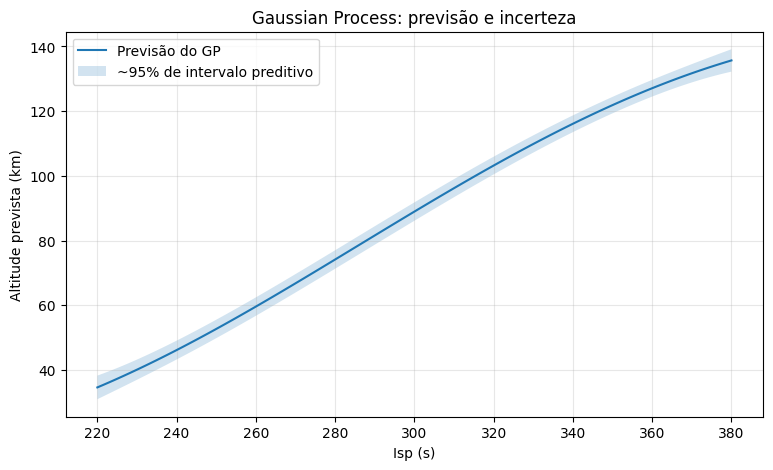

In [ ]:
isp_grid = np.linspace(220, 380, 120)
X_grid = pd.DataFrame({
    "isp": isp_grid,
    "thrust_N": 22_000,
    "propellant_mass_kg": 0.65 * VEHICLE_MASS,
    "cd": 0.45,
    "area_m2": 0.8,
})
scaler = gp.named_steps["standardscaler"]
gpr = gp.named_steps["gaussianprocessregressor"]
X_grid_scaled = scaler.transform(X_grid)
mean_pred, std_pred = gpr.predict(X_grid_scaled, return_std=True)

plt.figure(figsize=(9, 5))
plt.plot(isp_grid, mean_pred, label="Previsão do GP")
plt.fill_between(isp_grid, mean_pred - 1.96*std_pred, mean_pred + 1.96*std_pred,
                 alpha=0.2, label="~95% de intervalo preditivo")
plt.xlabel("Isp (s)")
plt.ylabel("Altitude prevista (km)")
plt.title("Gaussian Process: previsão e incerteza")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 8. Bayesian Optimization simplificada

Usamos uma função de aquisição `Expected Improvement` para sugerir o próximo ponto promissor dentro de um espaço de parâmetros genéricos.

In [ ]:
def expected_improvement(mu, sigma, best_y, xi=0.01):
    sigma = np.maximum(sigma, 1e-9)
    improvement = mu - best_y - xi
    Z = improvement / sigma
    return improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

n_candidates = 2500
candidates = pd.DataFrame({
    "isp": np.random.uniform(220, 380, n_candidates),
    "thrust_N": np.random.uniform(14_000, 30_000, n_candidates),
    "propellant_mass_kg": np.random.uniform(0.45 * VEHICLE_MASS, 0.75 * VEHICLE_MASS, n_candidates),
    "cd": np.random.uniform(0.25, 0.8, n_candidates),
    "area_m2": np.random.uniform(0.4, 1.2, n_candidates),
})

cand_scaled = scaler.transform(candidates)
mu, sigma = gpr.predict(cand_scaled, return_std=True)
ei = expected_improvement(mu, sigma, y_train.max())
best_idx = np.argmax(ei)

suggestion = candidates.iloc[best_idx].copy()
suggestion["predicted_altitude_km"] = mu[best_idx]
suggestion["prediction_std_km"] = sigma[best_idx]
suggestion["expected_improvement"] = ei[best_idx]
suggestion


,1593
isp,354.368257
thrust_N,29561.091770
propellant_mass_kg,742.823500
cd,0.389712
area_m2,0.485045
predicted_altitude_km,264.057750
prediction_std_km,2.670465
expected_improvement,1.525337


## 9. Validando a sugestão com a física

O ponto sugerido pelo modelo volta para a simulação física antes de ser aceito.

In [ ]:
candidate_prop = float(suggestion["propellant_mass_kg"])
candidate_sim, candidate_bt = simulate_vertical_ascent(
    total_mass=VEHICLE_MASS,
    propellant_mass=candidate_prop,
    dry_mass=1000-candidate_prop,
    thrust=float(suggestion["thrust_N"]),
    isp=float(suggestion["isp"]),
    cd=float(suggestion["cd"]),
    area=float(suggestion["area_m2"]),
    max_time=180, dt=0.1)

physical_altitude = candidate_sim["altitude_km"].max()
print(f"Altitude prevista pelo GP: {suggestion['predicted_altitude_km']:.2f} km")
print(f"Altitude obtida na simulação física: {physical_altitude:.2f} km")
print(f"Desvio absoluto: {abs(physical_altitude-suggestion['predicted_altitude_km']):.2f} km")


Altitude prevista pelo GP: 264.06 km
Altitude obtida na simulação física: 341.46 km
Desvio absoluto: 77.40 km


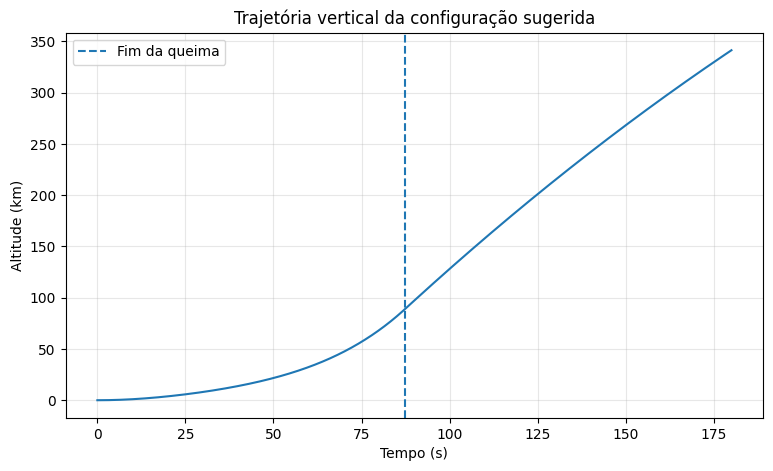

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(candidate_sim["time_s"], candidate_sim["altitude_km"])
plt.axvline(candidate_bt, linestyle="--", label="Fim da queima")
plt.xlabel("Tempo (s)")
plt.ylabel("Altitude (km)")
plt.title("Trajetória vertical da configuração sugerida")
plt.legend(); plt.grid(alpha=0.3); plt.show()


## 10. Experimentos para estudar

Experimente alterar uma variável por vez: `Isp`, empuxo, massa de propelente, área frontal ou coeficiente de arrasto. Compare o `delta-v` ideal de Tsiolkovsky com o comportamento dinâmico e observe onde a incerteza do surrogate cresce.

Uma extensão acadêmica natural é estudar um problema multiobjetivo, por exemplo: altitude, massa de propelente e energia.

O fluxo conceitual do notebook é:

\[
\text{Física} \rightarrow \text{Simulação} \rightarrow \text{Dataset} \rightarrow \text{Machine Learning} \rightarrow \text{Otimização} \rightarrow \text{Validação física}
\]
